In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/dataset.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(114000, 21)
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                       

In [2]:
#checking for nulls
print(df.info())
print("\nNull values per column:")
print(df.isnull().sum())
print("\nPopularity range:", df['popularity'].describe())

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [3]:
df = df.dropna(subset=['artists', 'album_name', 'track_name'])
df = df[df['speechiness'] < 0.66]  # drop podcasts/non-music
df = df.drop_duplicates(subset=['track_name', 'artists'])

print(f"Clean dataset: {df.shape[0]:,} tracks remaining")
df.to_csv('../data/clean_spotify.csv', index=False)
print("Saved to /data/clean_spotify.csv")

Clean dataset: 80,481 tracks remaining
Saved to /data/clean_spotify.csv


In [4]:
# popularity tiers
df['popularity_tier'] = df['popularity'].apply(lambda s: 'Low' if s <= 40 else 'Mid' if s <= 70 else 'High')

def mood_quadrant(row):
    v, e = row['valence'], row['energy']
    if v >= 0.5 and e >= 0.5: return 'Party'
    elif v >= 0.5: return 'Chill'
    elif e >= 0.5: return 'Intense'
    else: return 'Melancholic'

#mood distribution
df['mood'] = df.apply(mood_quadrant, axis=1)
print(df['mood'].value_counts())
print("\nAverage popularity per mood:")
print(df.groupby('mood')['popularity'].mean().sort_values(ascending=False).round(2))

mood
Party          29304
Intense        27318
Melancholic    17501
Chill           6358
Name: count, dtype: int64

Average popularity per mood:
mood
Party          35.25
Intense        35.17
Melancholic    34.37
Chill          31.78
Name: popularity, dtype: float64


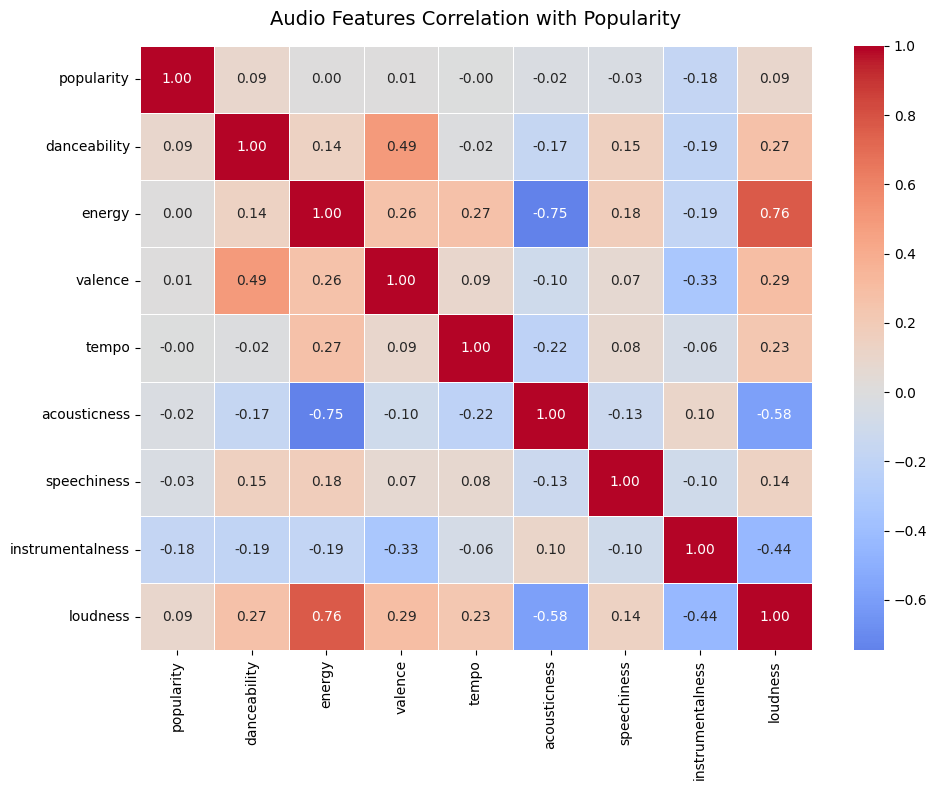

Heatmap saved to /outputs folder 


In [5]:
# correlation heatmap
plt.figure(figsize=(10, 8))

features = ['popularity', 'danceability', 'energy', 'valence', 'tempo', 'acousticness', 'speechiness', 
            'instrumentalness', 'loudness']

corr = df[features].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)

plt.title('Audio Features Correlation with Popularity', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved to /outputs folder ")

In [6]:
# compare avg audio features between high and low popularity songs
high = df[df['popularity_tier'] == 'High']
low = df[df['popularity_tier'] == 'Low']

features = ['danceability','energy','valence','acousticness','instrumentalness','loudness']

comparison = pd.DataFrame({
    'High Popularity': high[features].mean().round(3),
    'Low Popularity': low[features].mean().round(3)
})
comparison['Difference'] = (comparison['High Popularity'] - comparison['Low Popularity']).round(3)
print(comparison.sort_values('Difference', ascending=False))

                  High Popularity  Low Popularity  Difference
loudness                   -6.710          -8.785       2.075
danceability                0.622           0.546       0.076
valence                     0.504           0.472       0.032
energy                      0.661           0.643       0.018
acousticness                0.235           0.323      -0.088
instrumentalness            0.035           0.219      -0.184


Top 10 Genres by Average Popularity:
track_genre
k-pop                59.33
pop-film             59.12
metal                56.45
pop                  55.91
chill                55.20
hip-hop              52.53
sad                  51.81
latino               51.17
grunge               50.56
singer-songwriter    49.83
Name: popularity, dtype: float64


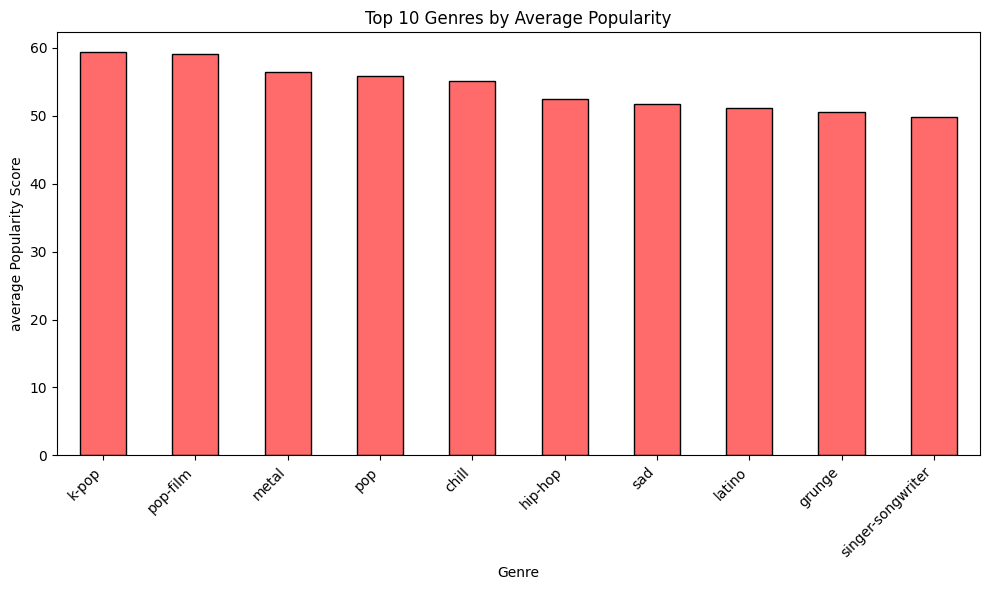

chart saved


In [7]:
# genres with the highest avg popularity
top_genres = (df.groupby('track_genre')['popularity']
                .mean()
                .sort_values(ascending=False)
                .head(10)
                .round(2))

print("Top 10 Genres by Average Popularity:")
print(top_genres)

# bar chart
plt.figure(figsize=(10, 6))
top_genres.plot(kind='bar', color='#FF6B6B', edgecolor='black')
plt.title('Top 10 Genres by Average Popularity')
plt.xlabel('Genre')
plt.ylabel('average Popularity Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/genre_popularity.png', dpi=150)
plt.show()
print("chart saved")

In [8]:
#file save
df.to_csv('../outputs/spotify_powerbi_ready.csv', index=False)
print("saved")

saved
